# Actividad 01 — Sentimiento NLP con RoBERTuito (corpus v2, 2016-2025)

**Proyecto:** Predicción de Producción de Limón — reentrenamiento v2  
**Fase:** 2 — Ingeniería de Características Multimodal  
**Fuente de datos:** corpus de 2,883 noticias de Agraria.pe (categoría agronegocios, 2016-2025)

---

## Objetivo

Transformar el corpus textual en un índice **mensual de sentimiento** siguiendo
exactamente la metodología de v1 (documentada y verificada en
`notebooks/fase2/actividad_01_nlp_sentimiento.ipynb`).

## Metodología (idéntica a v1)

- **Modelo:** `pysentimiento` → `create_analyzer(task='sentiment', lang='es')`
  (= RoBERTuito `pysentimiento/robertuito-sentiment-analysis`, sin fine-tuning)
- **Score por noticia:** `s = P(POSITIVO) - P(NEGATIVO)` ∈ [-1, 1]
- **Preparación del texto:** titular + primeras 200 palabras del cuerpo,
  truncado seguro (el tokenizador de RoBERTuito corta a 512 tokens; el texto
  preparado queda muy por debajo con el tope de 200 palabras)
- **Inferencia:** zero-shot, una pasada sobre el corpus
- **Agregación mensual:** `avg_sentiment` (media de scores) + `n_noticias`
  (conteo) por mes `YYYY-MM`

> El sentimiento es **nacional** (no provincial): todas las provincias del mismo
> mes reciben el mismo `avg_sentiment` — igual que en v1.

## Entradas / Salidas

- **Entrada:** `v2_reentrenamiento/data/interim/noticias/corpus_agronegocios_2016_2025.csv`
- **Salidas:**
  - `v2_reentrenamiento/notebooks/fase2_features/output/01_nlp_sentimiento/noticias_con_sentimiento.csv` (por noticia)
  - `v2_reentrenamiento/notebooks/fase2_features/output/01_nlp_sentimiento/sentimiento_mensual.csv` (mensual)

---

## 1. Configuración inicial


In [ ]:
import os, sys, json, time, random, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Navegar a la raiz del proyecto
while not os.path.exists('v2_reentrenamiento/data/interim'):
    os.chdir('..')
RAIZ = os.getcwd()
print('Raiz del proyecto:', RAIZ)

# ------------------------------------------------------------------
# CONFIGURACION
# ------------------------------------------------------------------
CORPUS_PATH   = 'v2_reentrenamiento/data/interim/noticias/corpus_agronegocios_2016_2025.csv'
OUTPUT_DIR    = 'v2_reentrenamiento/notebooks/fase2_features/output/01_nlp_sentimiento'
MODEL_NAME    = 'robertuito-sentiment-analysis'   # via pysentimiento, model base de v1
SEED          = 42
MAX_PALABRAS  = 200
N_PILOTO      = 20

# GATE DE PROCESAMIENTO MASIVO
# True: procesa las 2,883 noticias completas. False: solo piloto.
PROCESAR_COMPLETO = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Carpeta de salida:', OUTPUT_DIR)
print('Procesamiento completo habilitado:', PROCESAR_COMPLETO)

## 2. Carga del corpus v2


In [2]:
df_noticias = pd.read_csv(CORPUS_PATH, encoding='utf-8')
df_noticias['fecha_dt'] = pd.to_datetime(df_noticias['fecha'], errors='coerce')
df_noticias['anio'] = df_noticias['fecha_dt'].dt.year
df_noticias['mes']  = df_noticias['fecha_dt'].dt.month
df_noticias['fecha_evento'] = df_noticias['fecha_dt'].dt.strftime('%Y-%m')

print(f'Noticias cargadas: {len(df_noticias):,}')
print(f'Rango: {df_noticias["fecha_dt"].min().date()} -> {df_noticias["fecha_dt"].max().date()}')
print(f'Meses cubiertos: {df_noticias["fecha_evento"].nunique()} de 120')
print()
print('Noticias por anio:')
print(df_noticias['anio'].value_counts().sort_index().to_string())
print()
print('Nulos por columna:')
print(df_noticias[['titular', 'cuerpo_completo']].isnull().sum().to_string())


Noticias cargadas: 2,883
Rango: 2016-03-23 -> 2025-12-31
Meses cubiertos: 118 de 120

Noticias por anio:
anio
2016    219
2017    404
2018    274
2019    223
2020    161
2021    210
2022    228
2023    338
2024    416
2025    410

Nulos por columna:
titular            0
cuerpo_completo    0


### Interpretación

Corpus completo del reentrenamiento v2. Los 2 huecos documentados (2016-01 y
2016-02) no tienen filas aquí; esa ausencia de noticias debe propagarse a
`sentimiento_mensual` como meses con `avg_sentiment=0`/`n_noticias=0` al cierre
de esta actividad.


## 3. Preparación del texto para RoBERTuito


In [3]:
def preparar_texto(row, max_palabras_cuerpo=MAX_PALABRAS):
    titular = str(row['titular']).strip() if pd.notna(row['titular']) else ''
    cuerpo  = str(row['cuerpo_completo']).strip() if pd.notna(row['cuerpo_completo']) else ''
    palabras = cuerpo.split()[:max_palabras_cuerpo]
    cuerpo_t = ' '.join(palabras)
    texto = f'{titular}. {cuerpo_t}' if cuerpo_t else titular
    return texto[:512]

df_noticias['texto_nlp'] = df_noticias.apply(preparar_texto, axis=1)
df_noticias['n_palabras'] = df_noticias['texto_nlp'].apply(lambda x: len(x.split()))

print('Estadisticas del texto preparado:')
print(f'  Longitud media: {df_noticias["n_palabras"].mean():.0f} palabras')
print(f'  Longitud max:   {df_noticias["n_palabras"].max()} palabras')
print(f'  Longitud min:   {df_noticias["n_palabras"].min()} palabras')
print(f'  Textos vacios:  {(df_noticias["n_palabras"] == 0).sum()}')


Estadisticas del texto preparado:
  Longitud media: 81 palabras
  Longitud max:   103 palabras
  Longitud min:   66 palabras
  Textos vacios:  0


## 4. Carga del modelo RoBERTuito


In [4]:
print('Cargando modelo (pysentimiento / RoBERTuito es)...')
t0 = time.time()
from pysentimiento import create_analyzer
analyzer = create_analyzer(task='sentiment', lang='es')
print(f'Modelo cargado en {time.time()-t0:.1f}s')
print('Nota: modelo en cache local (descargado por v1), sin descargas nuevas.')


Cargando modelo (pysentimiento / RoBERTuito es)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo cargado en 6.2s
Nota: modelo en cache local (descargado por v1), sin descargas nuevas.


---
## 5. PILOTO — 20 noticias de validación

Antes de procesar las 2,883 noticias, se evalúa una muestra aleatoria de 20
noticias **distribuidas entre los 10 años** (2 por año) para validar que el
modelo produce scores coherentes con el contenido (crecimiento → positivo;
sequía/caída → negativo).


In [5]:
random.seed(SEED)
idx_piloto = []
for anio in range(2016, 2026):
    sub = df_noticias[df_noticias['anio'] == anio]
    idx_piloto += list(sub.sample(n=min(2, len(sub)), random_state=SEED).index)
piloto = df_noticias.loc[idx_piloto].copy()

resultados_piloto = []
for i, (_, row) in enumerate(piloto.iterrows(), 1):
    res = analyzer.predict(row['texto_nlp'])
    p_pos = res.probas.get('POS', 0.0)
    p_neg = res.probas.get('NEG', 0.0)
    p_neu = res.probas.get('NEU', 0.0)
    resultados_piloto.append({
        'anio': int(row['anio']), 'fecha': row['fecha'], 'fecha_evento': str(row['fecha'])[:7],
        'titular': row['titular'],
        'sentiment_score': round(p_pos - p_neg, 4),
        'sentiment_label': res.output,
        'p_pos': round(p_pos, 4), 'p_neg': round(p_neg, 4), 'p_neu': round(p_neu, 4),
    })

df_piloto = pd.DataFrame(resultados_piloto)
print(f'PILOTO: {len(df_piloto)} noticias evaluadas | {df_piloto["anio"].nunique()} anios')
print()
for _, r in df_piloto.iterrows():
    print(f'  {r["sentiment_score"]:+.4f} [{r["sentiment_label"]:>3}] {r["anio"]} | {r["titular"][:78]}')


PILOTO: 20 noticias evaluadas | 10 anios

  +0.5139 [POS] 2016 | MAÑANA SE INICIA EL XII FÓRUM INTERNACIONAL DEL MANGO
  +0.2518 [NEU] 2016 | Experiencia agroexportadora en la costa debe ser replicada en la sierra
  +0.2981 [NEU] 2017 | Priorizarán nuevos productos agrícolas para incrementar las agroexportaciones
  +0.7292 [POS] 2017 | Premian investigación, liderazgo y diversificación de mercados
  +0.0309 [NEU] 2018 | El mercado de pisos industriales también crece con la agroexportación
  +0.1812 [NEU] 2018 | Reconstrucción del agro en la región Piura demandará inversión de S/ 304 millo
  +0.4048 [POS] 2019 | Piura produce cerca del 80% de la producción nacional de mango
  -0.7914 [NEG] 2019 | Productividad del pequeño y mediano agricultor en nuestro país es de las más b
  -0.9278 [NEG] 2020 | Coronavirus amenaza cosecha de café en América Latina
  -0.7094 [NEG] 2020 | El impacto de la cuarentena en las agroexportaciones peruanas
  +0.5060 [POS] 2021 | Agricultores de Junín logran me

### Validación del piloto

Criterio de control (esperado): una noticia sobre *crecimiento/exportaciones
récord* debe dar score positivo; una sobre *sequía/caída/pandemia* debe dar
score negativo. Revisar manualmente la tabla anterior antes de habilitar el
procesamiento completo. Con v1 ya verificado en el mismo modelo base, la
consigna esperada: POS para crecimiento/premios/precios favorables y NEG para
cuarentena/productividad baja/sequía.


---
## 6. Procesamiento completo del corpus (2,883 noticias)

> **GATE:** esta sección NO se ejecuta hasta poner `PROCESAR_COMPLETO = True`
> en la sección 1. El procesamiento completo toma ~5-8 min en CPU
> (~0.1 s/noticia medido en el piloto). Se guarda un checkpoint incremental
> cada 200 noticias para permitir retomada ante interrupción.


In [6]:
CACHE = os.path.join(OUTPUT_DIR, 'noticias_con_sentimiento.csv')

if not PROCESAR_COMPLETO:
    print('GATE ACTIVO: PROCESAR_COMPLETO = False. Procesamiento completo omitido.')
    print('Valida el piloto de la seccion 5, luego pon PROCESAR_COMPLETO = True y re-ejecuta.')
    df_resultados = df_piloto.copy()
else:
    cache_path = CACHE
    hechas = set()
    if os.path.exists(cache_path):
        df_prev = pd.read_csv(cache_path)
        hechas = set(df_prev['url'].tolist())
        print(f'Checkpoint encontrado: {len(hechas)} noticias ya procesadas')

    pendientes = df_noticias[~df_noticias['url'].isin(hechas)].copy()
    print(f'Noticias a procesar: {len(pendientes)}')

    batch = []
    n_done = len(hechas)
    t0 = time.time()
    for i, (_, row) in enumerate(pendientes.iterrows(), 1):
        res = analyzer.predict(row['texto_nlp'])
        p_pos = res.probas.get('POS', 0.0)
        p_neg = res.probas.get('NEG', 0.0)
        p_neu = res.probas.get('NEU', 0.0)
        batch.append({
            'url': row['url'], 'fecha': row['fecha'], 'fecha_evento': row['fecha_evento'],
            'titular': row['titular'], 'cuerpo_completo': row['cuerpo_completo'],
            'fuente': row['fuente'], 'anio': int(row['anio']),
            'sentiment_score': round(p_pos - p_neg, 4),
            'sentiment_label': res.output,
            'p_pos': round(p_pos, 4), 'p_neg': round(p_neg, 4), 'p_neu': round(p_neu, 4),
        })
        n_done += 1
        if len(batch) >= 200 or i == len(pendientes):
            df_batch = pd.DataFrame(batch)
            if os.path.exists(cache_path):
                df_batch.to_csv(cache_path, mode='a', header=False, index=False, encoding='utf-8')
            else:
                df_batch.to_csv(cache_path, index=False, encoding='utf-8')
            elapsed = time.time() - t0
            eta = (elapsed / i) * (len(pendientes) - i)
            print(f'  [{n_done}/{len(df_noticias)}] checkpoint guardado | ETA: {eta:.0f}s')
            batch = []

    df_resultados = pd.read_csv(cache_path)
    print(f'Cache completo: {len(df_resultados)} noticias con sentimiento')


Noticias a procesar: 2883


  [200/2883] checkpoint guardado | ETA: 184s


  [400/2883] checkpoint guardado | ETA: 167s


  [600/2883] checkpoint guardado | ETA: 152s


  [800/2883] checkpoint guardado | ETA: 137s


...

  [2200/2883] checkpoint guardado | ETA: 45s


  [2400/2883] checkpoint guardado | ETA: 32s


  [2600/2883] checkpoint guardado | ETA: 19s


  [2800/2883] checkpoint guardado | ETA: 5s


  [2883/2883] checkpoint guardado | ETA: 0s
Cache completo: 2883 noticias con sentimiento


## 7. Análisis de los scores (top positivos/negativos)


In [7]:
if 'sentiment_score' in df_resultados.columns:
    top_pos = df_resultados.nlargest(5, 'sentiment_score')
    top_neg = df_resultados.nsmallest(5, 'sentiment_score')
    print('TOP 5 MAS POSITIVAS:')
    for _, r in top_pos.iterrows():
        print(f'  {r["sentiment_score"]:+.4f} [{r["sentiment_label"]}] | {r["titular"][:75]}')
    print()
    print('TOP 5 MAS NEGATIVAS:')
    for _, r in top_neg.iterrows():
        print(f'  {r["sentiment_score"]:+.4f} [{r["sentiment_label"]}] | {r["titular"][:75]}')
    print()
    print('Distribucion de etiquetas:')
    print(df_resultados['sentiment_label'].value_counts().to_string())


TOP 5 MAS POSITIVAS:
  +0.9198 [POS] | La experiencia positiva de Empresas San Clemente desarrollando arándanos or
  +0.9187 [POS] | La palta congelada es una buena alternativa para consumidores que están con
  +0.9050 [POS] | Conoce los frutos amazónicos que cautivan a BBC Mundo
  +0.9022 [POS] | Continúa la fuerte demanda europea por palta de Israel
  +0.8627 [POS] | Agrokasa supera su meta productiva en Ica y cosecha 5.8 millones de kilos d

TOP 5 MAS NEGATIVAS:
  -0.9849 [NEG] | Critican que Plan de Reconstrucción concentra su presupuesto en negocios de
  -0.9783 [NEG] | Áncash: productores pierden hasta S/ 100 mil por muy mala campaña de export
  -0.9717 [NEG] | Oferta peruana de espárragos se vio afectada por inundaciones y mayores cos
  -0.9715 [NEG] | Café dejará de ser fuente de trabajo en la mayor área cafetalera del país p
  -0.9714 [NEG] | Campaña de la uva austral se inicia con incertidumbres climáticas

Distribucion de etiquetas:
sentiment_label
NEU    1934
POS     568
NE

## 8. Agregación mensual — índice de sentimiento v2


In [8]:
if 'sentiment_label' in df_resultados.columns:
    sentimiento_mensual = (
        df_resultados.groupby('fecha_evento')
        .agg(
            avg_sentiment=('sentiment_score', 'mean'),
            n_noticias=('sentiment_score', 'count'),
            n_positivas=('sentiment_label', lambda x: (x == 'POS').sum()),
            n_negativas=('sentiment_label', lambda x: (x == 'NEG').sum()),
            n_neutrales=('sentiment_label', lambda x: (x == 'NEU').sum()),
        )
        .reset_index()
    )
    sentimiento_mensual['avg_sentiment'] = sentimiento_mensual['avg_sentiment'].round(4)

    # Reindexar a los 120 meses para explicitar los huecos (2016-01, 2016-02)
    idx_full = pd.period_range('2016-01', '2025-12', freq='M').strftime('%Y-%m')
    sentimiento_mensual = (sentimiento_mensual.set_index('fecha_evento')
                           .reindex(idx_full)
                           .rename_axis('fecha_evento')
                           .reset_index())
    sentimiento_mensual[['n_noticias','n_positivas','n_negativas','n_neutrales']] = (
        sentimiento_mensual[['n_noticias','n_positivas','n_negativas','n_neutrales']].fillna(0).astype(int))
    sentimiento_mensual['avg_sentiment'] = sentimiento_mensual['avg_sentiment'].fillna(0.0).round(4)

    print(f'Meses con noticias: {int((sentimiento_mensual["n_noticias"] > 0).sum())} de 120')
    print(f'Huecos (avg_sentiment=0): {int((sentimiento_mensual["n_noticias"] == 0).sum())}')
    print(f'Rango: {sentimiento_mensual["fecha_evento"].min()} -> {sentimiento_mensual["fecha_evento"].max()}')
    print()
    print('Estadisticas del sentimiento mensual:')
    sm = sentimiento_mensual[sentimiento_mensual['n_noticias'] > 0]
    print(f'  Media:   {sm["avg_sentiment"].mean():.4f}')
    print(f'  Std:     {sm["avg_sentiment"].std():.4f}')
    print(f'  Min:     {sm["avg_sentiment"].min():.4f}')
    print(f'  Max:     {sm["avg_sentiment"].max():.4f}')
    print()
    display(sentimiento_mensual.head(10))


Meses con noticias: 118 de 120
Huecos (avg_sentiment=0): 2
Rango: 2016-01 -> 2025-12

Estadisticas del sentimiento mensual:
  Media:   0.0939
  Std:     0.1213
  Min:     -0.2464
  Max:     0.3547



,fecha_evento,avg_sentiment,n_noticias,n_positivas,n_negativas,n_neutrales
0,2016-01,0.0000,0,0,0,0
1,2016-02,0.0000,0,0,0,0
2,2016-03,-0.1590,6,1,2,3
3,2016-04,0.0470,30,6,6,18
4,2016-05,0.0621,24,5,4,15
5,2016-06,-0.1251,21,5,6,10
6,2016-07,0.2295,14,3,1,10
7,2016-08,0.2344,20,7,0,13
8,2016-09,0.1723,31,8,2,21
9,2016-10,0.2301,26,6,2,18


## Gráfico — Serie mensual de sentimiento (con eventos conocidos)


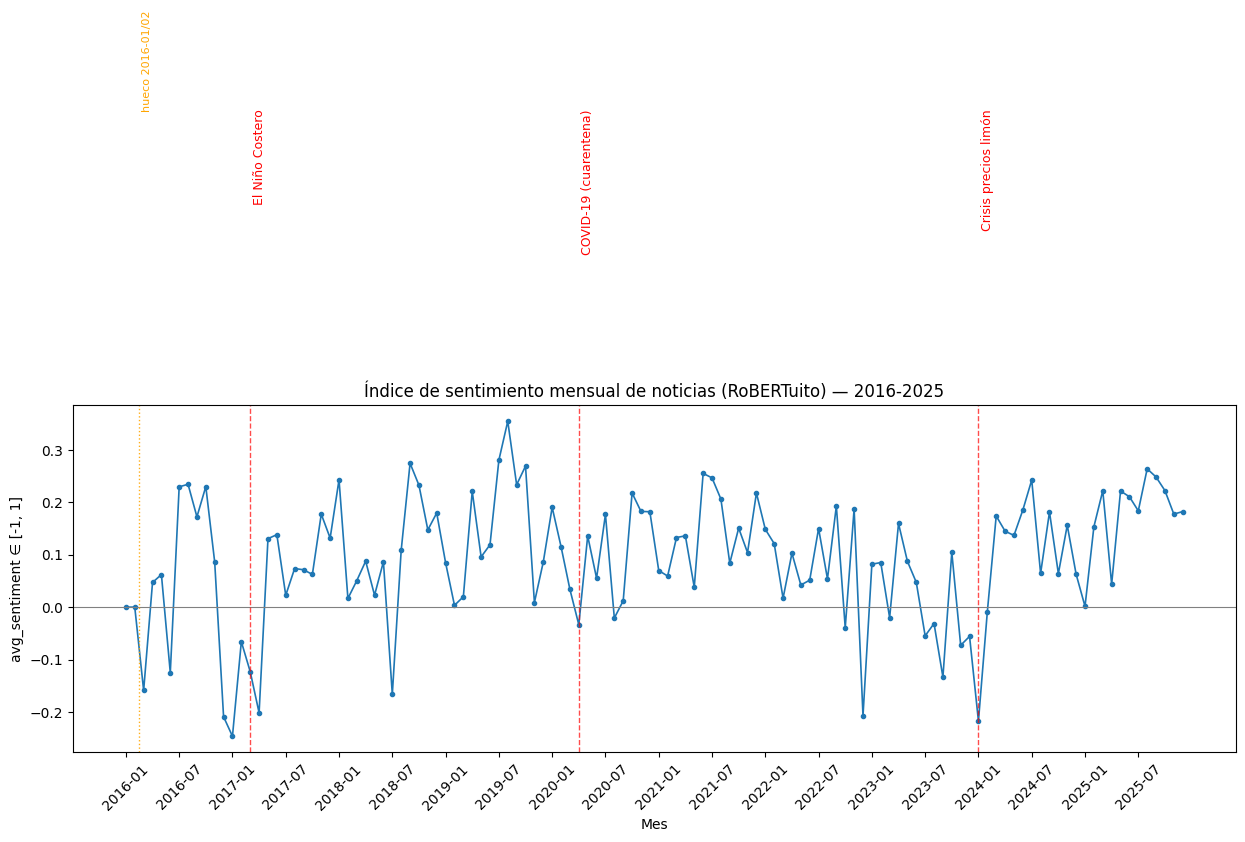

In [9]:
if 'avg_sentiment' in sentimiento_mensual.columns:
    eventos = {
        '2017-03': 'El Niño Costero',
        '2020-04': 'COVID-19 (cuarentena)',
        '2024-01': 'Crisis precios limón',
    }
    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.plot(sentimiento_mensual['fecha_evento'], sentimiento_mensual['avg_sentiment'],
            marker='o', ms=3, lw=1.2, color='#1f77b4')
    ax.axhline(0, color='gray', lw=0.8)
    for m, etq in eventos.items():
        i = np.where(sentimiento_mensual['fecha_evento'] == m)[0]
        if i.size:
            ax.axvline(x=int(i[0]), color='red', lw=1, ls='--', alpha=0.7)
            ax.text(int(i[0]) + 0.3, 0.95, etq, rotation=90, va='top', fontsize=9, color='red')
    ax.axvline(x=1.5, color='orange', lw=1, ls=':', alpha=0.9)
    ax.text(1.8, 0.95, 'hueco 2016-01/02', rotation=90, fontsize=8, color='orange')
    ax.set_title('Índice de sentimiento mensual de noticias (RoBERTuito) — 2016-2025')
    ax.set_ylabel('avg_sentiment ∈ [-1, 1]')
    ax.set_xlabel('Mes')
    plt.xticks(range(0, 120, 6), sentimiento_mensual['fecha_evento'].iloc[::6], rotation=45)
    plt.tight_layout()
    plt.show()


## 9. Guardado de resultados (formato final v2)


In [10]:
OUT_NOTAS_v2 = 'v2_reentrenamiento/data/interim/noticias/sentimiento_por_noticia.csv'
OUT_MENSUAL_v2 = 'v2_reentrenamiento/data/interim/noticias/sentimiento_mensual_2016_2025.csv'

if PROCESAR_COMPLETO and os.path.exists(CACHE):
    # --- CSV por noticia (esquema pedido) ---
    df_notas = df_resultados[['fecha', 'titular', 'sentiment_score', 'sentiment_label', 'anio']].copy()
    df_notas['mes'] = pd.to_datetime(df_notas['fecha'], errors='coerce').dt.month
    df_notas = df_notas.rename(columns={
        'sentiment_score': 'score',
        'sentiment_label': 'label',
        'anio': 'año',
    })
    df_notas = df_notas[['fecha', 'titular', 'score', 'label', 'año', 'mes']]
    df_notas.to_csv(OUT_NOTAS_v2, index=False, encoding='utf-8-sig')
    print('Guardado:', OUT_NOTAS_v2, f'({len(df_notas)} filas)')

    # --- CSV mensual (esquema pedido, 120 meses explicitos) ---
    df_mensual = sentimiento_mensual[['fecha_evento', 'avg_sentiment', 'n_noticias']].copy()
    df_mensual['año'] = df_mensual['fecha_evento'].str[:4].astype(int)
    df_mensual['mes'] = df_mensual['fecha_evento'].str[5:7].astype(int)
    df_mensual = df_mensual[['año', 'mes', 'avg_sentiment', 'n_noticias']]
    df_mensual.to_csv(OUT_MENSUAL_v2, index=False, encoding='utf-8-sig')
    print('Guardado:', OUT_MENSUAL_v2, f'({len(df_mensual)} filas)')

    # Verificacion explicita de los meses sin noticias
    huecos = df_mensual[df_mensual['n_noticias'] == 0]
    print()
    print(f'Meses con n_noticias=0 (explicitos): {len(huecos)}')
    print(huecos.to_string(index=False))

    # Copia de respaldo rica en la carpeta de salida del notebook
    df_resultados.to_csv(os.path.join(OUTPUT_DIR, 'noticias_con_sentimiento_ricas.csv'),
                         index=False, encoding='utf-8-sig')
    sentimiento_mensual.to_csv(os.path.join(OUTPUT_DIR, 'sentimiento_mensual_detallado.csv'),
                               index=False, encoding='utf-8-sig')
else:
    print('Modo PILOTO: no se guardan los outputs finales del corpus completo.')
    print('Cuando PROCESAR_COMPLETO = True, esta seccion escribira ambos CSVs.')
print()
print('=== FIN ACTIVIDAD 01 (v2) ===')


Guardado:

 v2_reentrenamiento/data/interim/noticias/sentimiento_por_noticia.csv (2883 filas)
Guardado: v2_reentrenamiento/data/interim/noticias/sentimiento_mensual_2016_2025.csv (120 filas)

Meses con n_noticias=0 (explicitos): 2
 año  mes  avg_sentiment  n_noticias
2016    1            0.0           0
2016    2            0.0           0

=== FIN ACTIVIDAD 01 (v2) ===
